<a href="https://colab.research.google.com/github/vardhamanadarsh/Stock-price-prediction-using-deep-learning-models/blob/main/Copy_of_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Numerical computations
import numpy as np
import pandas as pd

# Data download
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt

# Wavelet Transform
import pywt

# Data Normalization
from sklearn.preprocessing import MinMaxScaler

# Deep Learning
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Evaluation
from sklearn.metrics import mean_squared_error

In [ ]:
ticker = "000001.SS"

start_date = "1997-07-03"
end_date = "2022-01-24"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date
)

df.head()

/tmp/ipykernel_909/4117705256.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,000001.SS,000001.SS,000001.SS,000001.SS,000001.SS
Date,,,,,
1997-07-03,1150.623047,1194.676025,1149.939941,1194.676025,0
1997-07-04,1159.342041,1163.249023,1124.776001,1138.921021,0
1997-07-07,1096.818970,1163.447021,1085.572021,1161.707031,0
1997-07-08,1109.666016,1115.432983,1066.043945,1092.798950,0
1997-07-09,1120.840942,1122.673950,1104.086060,1113.640991,0


In [ ]:
df = df.sort_index()

print(df.index.is_monotonic_increasing)

True


In [ ]:
import pywt
import numpy as np

def wavelet_denoise(signal, wavelet='db4', level=2):

    coeffs = pywt.wavedec(signal, wavelet, level=level)

    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))

    coeffs[1:] = [
        pywt.threshold(c, threshold, mode='soft')
        for c in coeffs[1:]
    ]

    reconstructed = pywt.waverec(coeffs, wavelet)

    return reconstructed[:len(signal)]

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

df_denoised = df.copy()

for col in features:
    df_denoised[col] = wavelet_denoise(df[col].values)

/usr/local/lib/python3.12/dist-packages/pywt/_multilevel.py:43: UserWarning: Level value of 2 is too high: all coefficients will experience boundary effects.
  warnings.warn(


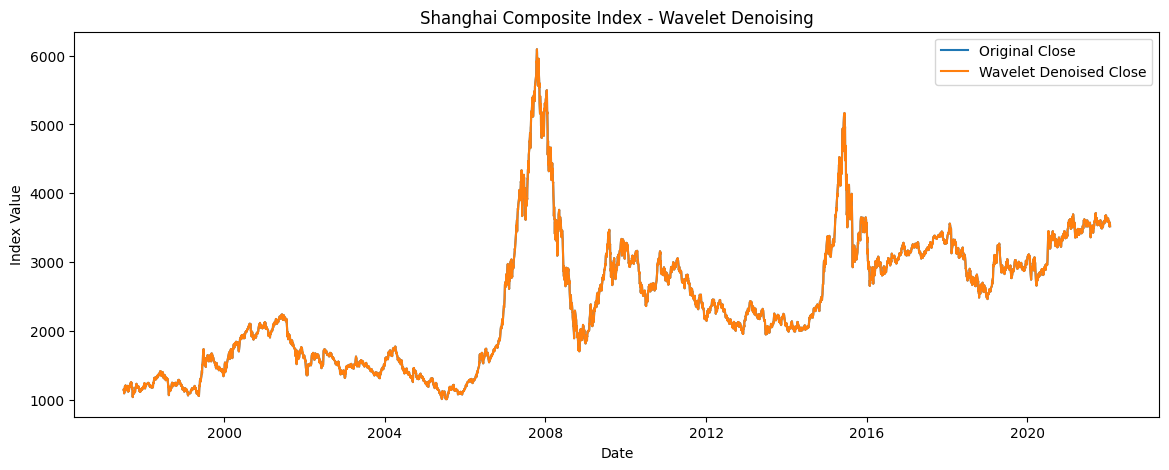

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(df['Close'], label='Original Close')
plt.plot(df_denoised['Close'], label='Wavelet Denoised Close')

plt.title("Shanghai Composite Index - Wavelet Denoising")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = ['Open', 'High', 'Low', 'Close', 'Volume']

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(df_denoised[features])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features,
    index=df_denoised.index
)

scaled_df.head()

,Open,High,Low,Close,Volume
Date,,,,,
1997-07-03,0.036989,0.034238,0.030087,0.027384,0.0
1997-07-04,0.025947,0.028081,0.025096,0.029100,0.0
1997-07-07,0.030459,0.028119,0.017322,0.016793,0.0
1997-07-08,0.016813,0.018713,0.013449,0.019322,0.0
1997-07-09,0.020941,0.020131,0.020993,0.021522,0.0


In [ ]:
# Sequence length from the paper
sequence_length = 55

# 85% train, 15% test
train_size = int(len(scaled_df) * 0.85)

train_data = scaled_df.iloc[:train_size]
test_data = scaled_df.iloc[train_size:]

print("Training samples:", len(train_data))
print("Testing samples :", len(test_data))

Training samples: 5057
Testing samples : 893


In [ ]:
def create_sequences(data, sequence_length):

    X = []
    y = []

    values = data.values

    for i in range(sequence_length, len(values)):

        X.append(values[i-sequence_length:i])

        # Close price is column index 3
        y.append(values[i, 3])

    return np.array(X), np.array(y)

In [ ]:
X_train, y_train = create_sequences(train_data, sequence_length)

In [ ]:
test_input = scaled_df.iloc[
    train_size-sequence_length:
]

X_test, y_test = create_sequences(
    test_input,
    sequence_length
)

In [ ]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (5002, 55, 5)
y_train: (5002,)
X_test : (893, 55, 5)
y_test : (893,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential()

model.add(
    LSTM(
        units=100,
        return_sequences=True,
        input_shape=(55, 5)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=100,
        return_sequences=True
    )
)

model.add(
    LSTM(
        units=150
    )
)

model.add(Dropout(0.2))

model.add(
    Dense(
        units=1,
        activation='linear'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 55, 100)        │        42,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 55, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 55, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273,551 (1.04 MB)

 Trainable params: 273,551 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=2,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 195ms/step - loss: 0.0019 - val_loss: 5.3996e-04
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 192ms/step - loss: 9.7821e-04 - val_loss: 3.2095e-04


In [ ]:
import os

os.makedirs("saved_models", exist_ok=True)

model.save("saved_models/lstm_stock_model.keras")

In [ ]:
# Predict normalized closing prices
predictions = model.predict(X_test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step


In [ ]:
# Dummy arrays for inverse transformation
pred_dummy = np.zeros((len(predictions), 5))
true_dummy = np.zeros((len(y_test), 5))

# Close price is column index 3
pred_dummy[:, 3] = predictions.flatten()
true_dummy[:, 3] = y_test

# Convert back to original prices
pred_close = scaler.inverse_transform(pred_dummy)[:, 3]
true_close = scaler.inverse_transform(true_dummy)[:, 3]

In [ ]:
# Actual movement
actual_change = np.diff(true_close) / true_close[:-1]

# Predicted movement
pred_change = np.diff(pred_close) / pred_close[:-1]

# Convert to labels
actual_labels = (actual_change > 0).astype(int)
pred_labels = (pred_change > 0).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(actual_labels, pred_labels)
precision = precision_score(actual_labels, pred_labels)
recall = recall_score(actual_labels, pred_labels)
f1 = f1_score(actual_labels, pred_labels)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.4944
Precision: 0.5010
Recall   : 0.5288
F1 Score : 0.5145


In [ ]:
cm = confusion_matrix(actual_labels, pred_labels)

tn, fp, fn, tp = cm.ravel()

print("True Positive :", tp)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)

True Positive : 239
True Negative : 202
False Positive: 238
False Negative: 213


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(true_close, pred_close))
mae = mean_absolute_error(true_close, pred_close)
r2 = r2_score(true_close, pred_close)

print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 91.0181
MAE  : 71.8352
R²   : 0.9268


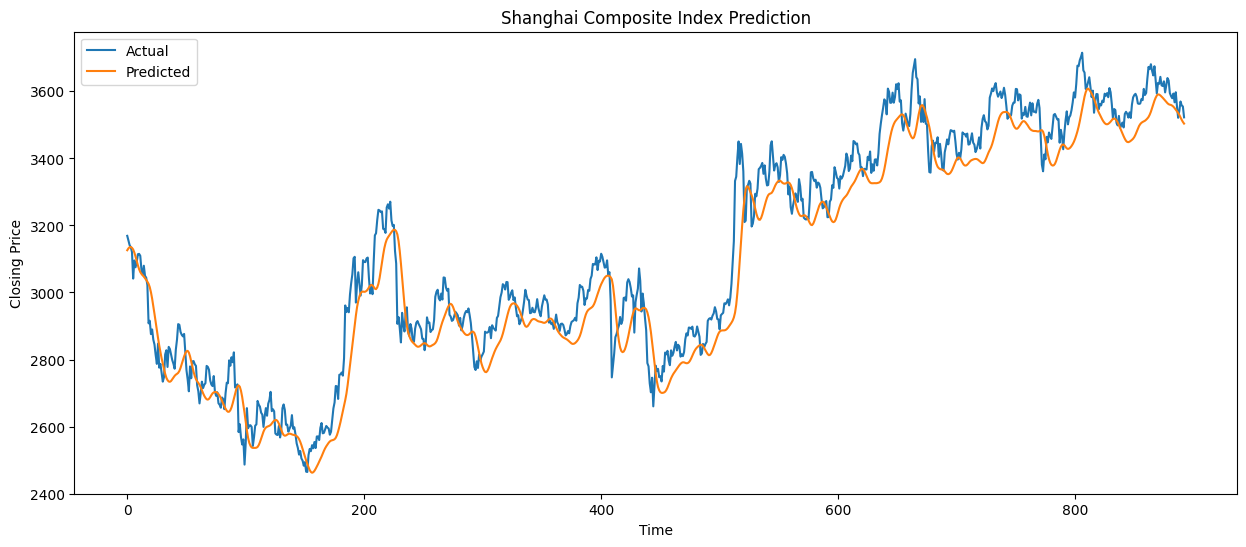

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(true_close, label="Actual")
plt.plot(pred_close, label="Predicted")

plt.title("Shanghai Composite Index Prediction")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [ ]:
actual_returns = (
    true_close[1:] - true_close[:-1]
) / true_close[:-1]

predicted_returns = (
    pred_close[1:] - pred_close[:-1]
) / pred_close[:-1]

In [ ]:
actual_labels = (actual_returns > 0).astype(int)
predicted_labels = (predicted_returns > 0).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(actual_labels, predicted_labels)
precision = precision_score(actual_labels, predicted_labels)
recall = recall_score(actual_labels, predicted_labels)
f1 = f1_score(actual_labels, predicted_labels)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.4944
Precision: 0.5010
Recall   : 0.5288
F1 Score : 0.5145
